### Distribuzione Target 'sii' Post-SMOTENC
Per ottenere la distribuzione del target dopo SMOTENC senza eseguire l'intero notebook, abbiamo bisogno di caricare i dati, dividere il set di training/testing, definire le colonne categoriche e inizializzare `smote_fast`.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

# Carica i dati
df = pd.read_csv('cmi_module1_clean-1.csv')

# Prepara X e y
X = df.drop(['sii'], axis=1)
y = df['sii']

# Split Stratificato (essenziale per mantenere le proporzioni delle classi rare)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [3]:
# Definisci le colonne categoriche
categorical_cols = ['Basic_Demos-Sex', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
                    'SDS_measured', 'BIA_measured', 'Metabolic_Alarms_Count', 'ScreenTime_Category',
                    'PreInt_EduHx-computerinternet_hoursday', ]
cat_idx = [X.columns.get_loc(c) for c in categorical_cols]

In [4]:
# Inizializza SMOTENC
smote_fast = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)

# Applica SMOTENC e mostra la distribuzione del target
X_train_resampled, y_train_resampled = smote_fast.fit_resample(X_train, y_train)

print("Distribuzione Target 'sii' (Training Set Post-SMOTENC):")
print(y_train_resampled.value_counts().sort_index())

Distribuzione Target 'sii' (Training Set Post-SMOTENC):
sii
0.0    4354
1.0    4354
2.0    4354
3.0    4354
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('cmi_module1_clean-1.csv')

# 1. Preparazione X e y
X = df.drop(['sii'], axis=1)
y = df['sii']

# Split Stratificato (essenziale per mantenere le proporzioni delle classi rare)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Conteggio Target Pre-SMOTENC
print("Distribuzione Target 'sii' (Training Set Originale):")
print(y_train.value_counts().sort_index())

# Scaling per k-NN Baseline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelli Baseline
dt_base = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
knn_base = KNeighborsClassifier(n_neighbors=10).fit(X_train_scaled, y_train)

# Valutazione Baseline
print("\n--- BASELINE DECISION TREE ---")
print(classification_report(y_test, dt_base.predict(X_test)))
print("\n--- BASELINE k-NN (k=10) ---")
print(classification_report(y_test, knn_base.predict(X_test_scaled)))

Distribuzione Target 'sii' (Training Set Originale):
sii
0.0    4354
1.0    1183
2.0     710
3.0      65
Name: count, dtype: int64

--- BASELINE DECISION TREE ---
              precision    recall  f1-score   support

         0.0       0.74      0.72      0.73      1452
         1.0       0.22      0.23      0.22       395
         2.0       0.22      0.23      0.23       237
         3.0       0.00      0.00      0.00        21

    accuracy                           0.57      2105
   macro avg       0.30      0.30      0.30      2105
weighted avg       0.58      0.57      0.57      2105


--- BASELINE k-NN (k=10) ---
              precision    recall  f1-score   support

         0.0       0.71      0.96      0.82      1452
         1.0       0.32      0.08      0.12       395
         2.0       0.33      0.05      0.08       237
         3.0       0.00      0.00      0.00        21

    accuracy                           0.69      2105
   macro avg       0.34      0.27      0.26   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured',
       'FGC_Muscular_Endurance', 'Social_Digital_Displacement',
       'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count',
       'ScreenTime_Age_Ratio', 'ScreenTime_Category'],
      dtype='object')

**SMOTE + Rounding**
*How it works:* Treats everything as decimal numbers. If it interpolates between "Male (0)" and "Female (1)", it might generate a "0.7". You would then have to force it to 1.
*Risk:* It generates feature combinations that may not exist in reality or that violate the logic of the original data.

**SMOTE-NC (Nominal and Continuous)**
*How it works:* You tell it which columns are categorical/ordinal. For these columns, instead of calculating a mathematical average, it uses the mode (the most frequent value) among the nearest neighbors.
*Why it's worth it:* It's much more robust. It maintains the integrity of the categorical data without the need for post-processing (no manual rounding that could smear the distribution).

In [ ]:
# Indici colonne categoriche
categorical_cols = ['Basic_Demos-Sex', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
                    'SDS_measured', 'BIA_measured', 'Metabolic_Alarms_Count', 'ScreenTime_Category',
                    'PreInt_EduHx-computerinternet_hoursday', ]
cat_idx = [X.columns.get_loc(c) for c in categorical_cols]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# --- 1. Parametri SMOTENC fissi per risparmiare tempo ---
# Lo estraiamo dalla griglia e lo fissiamo nella pipeline
smote_fast = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)

# --- 2. RandomizedSearch per Decision Tree ---
pipe_dt = ImbPipeline([
    ('smote', smote_fast),
    ('clf', DecisionTreeClassifier(random_state=42))
])

params_dt = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 10],
    'clf__min_samples_leaf': [1, 5]
}

# n_iter=20 significa che testerà solo 20 combinazioni casuali
grid_dt = RandomizedSearchCV(pipe_dt, params_dt, n_iter=20, cv=3,
                             scoring='f1_macro', n_jobs=-1, random_state=42).fit(X_train, y_train)

# --- 3. RandomizedSearch per k-NN ---
pipe_knn = ImbPipeline([
    ('smote', smote_fast),
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(metric='euclidean'))
])

params_knn = {
    'clf__n_neighbors': [3, 7, 15], # Ridotti i centri di ricerca
    'clf__weights': ['uniform', 'distance']
}

grid_knn = RandomizedSearchCV(pipe_knn, params_knn, n_iter=10, cv=3,
                              scoring='f1_macro', n_jobs=-1, random_state=42).fit(X_train, y_train)

# --- OUTPUT RISULTATI ---
print(f"Miglior DT: {grid_dt.best_params_}")
print(f"Miglior k-NN: {grid_knn.best_params_}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Miglior DT: {'clf__min_samples_split': 10, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'entropy'}
Miglior k-NN: {'clf__weights': 'uniform', 'clf__n_neighbors': 15}



[POST-SMOTENC] Report Decision Tree:
              precision    recall  f1-score   support

         0.0       0.76      0.66      0.71      1452
         1.0       0.24      0.29      0.26       395
         2.0       0.21      0.30      0.25       237
         3.0       0.00      0.00      0.00        21

    accuracy                           0.55      2105
   macro avg       0.30      0.31      0.31      2105
weighted avg       0.59      0.55      0.57      2105


[POST-SMOTENC] Report k-NN:
              precision    recall  f1-score   support

         0.0       0.78      0.55      0.64      1452
         1.0       0.21      0.28      0.24       395
         2.0       0.18      0.28      0.22       237
         3.0       0.02      0.19      0.04        21

    accuracy                           0.46      2105
   macro avg       0.30      0.32      0.28      2105
weighted avg       0.60      0.46      0.51      2105



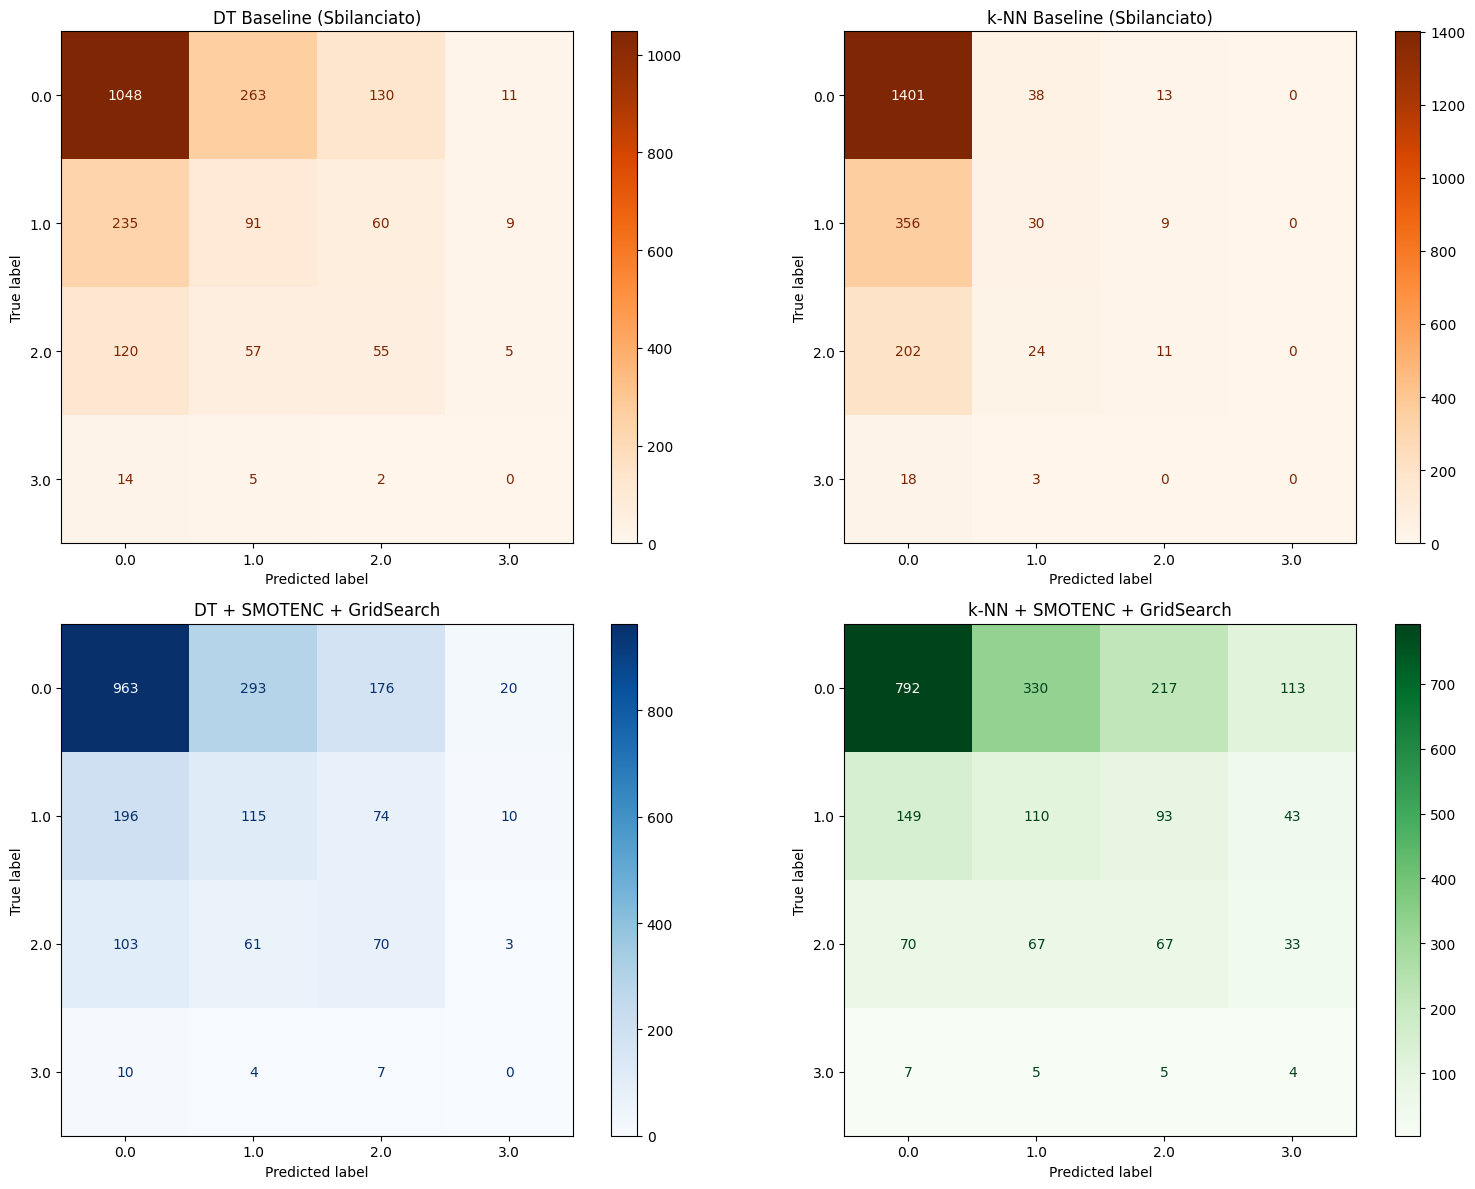


--- CONFRONTO MACRO F1-SCORE ---
DT Baseline: 0.296
DT Post-SMOTENC: 0.305
k-NN Baseline: 0.255
k-NN Post-SMOTENC: 0.284


In [ ]:
from sklearn.metrics import f1_score

# Predizioni modelli ottimizzati
y_pred_dt_sm = grid_dt.predict(X_test)
y_pred_knn_sm = grid_knn.predict(X_test)

# Report Post-SMOTENC
print("\n[POST-SMOTENC] Report Decision Tree:")
print(classification_report(y_test, y_pred_dt_sm))
print("\n[POST-SMOTENC] Report k-NN:")
print(classification_report(y_test, y_pred_knn_sm))

# Visualizzazione Confronto Matrici
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# Baseline
ConfusionMatrixDisplay.from_estimator(dt_base, X_test, y_test, ax=ax[0,0], cmap='Oranges')
ax[0,0].set_title("DT Baseline (Sbilanciato)")

ConfusionMatrixDisplay.from_estimator(knn_base, X_test_scaled, y_test, ax=ax[0,1], cmap='Oranges')
ax[0,1].set_title("k-NN Baseline (Sbilanciato)")

# Post-SMOTENC
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_sm, ax=ax[1,0], cmap='Blues')
ax[1,0].set_title("DT + SMOTENC + GridSearch")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_sm, ax=ax[1,1], cmap='Greens')
ax[1,1].set_title("k-NN + SMOTENC + GridSearch")

plt.tight_layout()
plt.show()

# Statistiche di confronto sintetiche
print("\n--- CONFRONTO MACRO F1-SCORE ---")
print(f"DT Baseline: {f1_score(y_test, dt_base.predict(X_test), average='macro'):.3f}")
print(f"DT Post-SMOTENC: {f1_score(y_test, y_pred_dt_sm, average='macro'):.3f}")
print(f"k-NN Baseline: {f1_score(y_test, knn_base.predict(X_test_scaled), average='macro'):.3f}")
print(f"k-NN Post-SMOTENC: {f1_score(y_test, y_pred_knn_sm, average='macro'):.3f}")

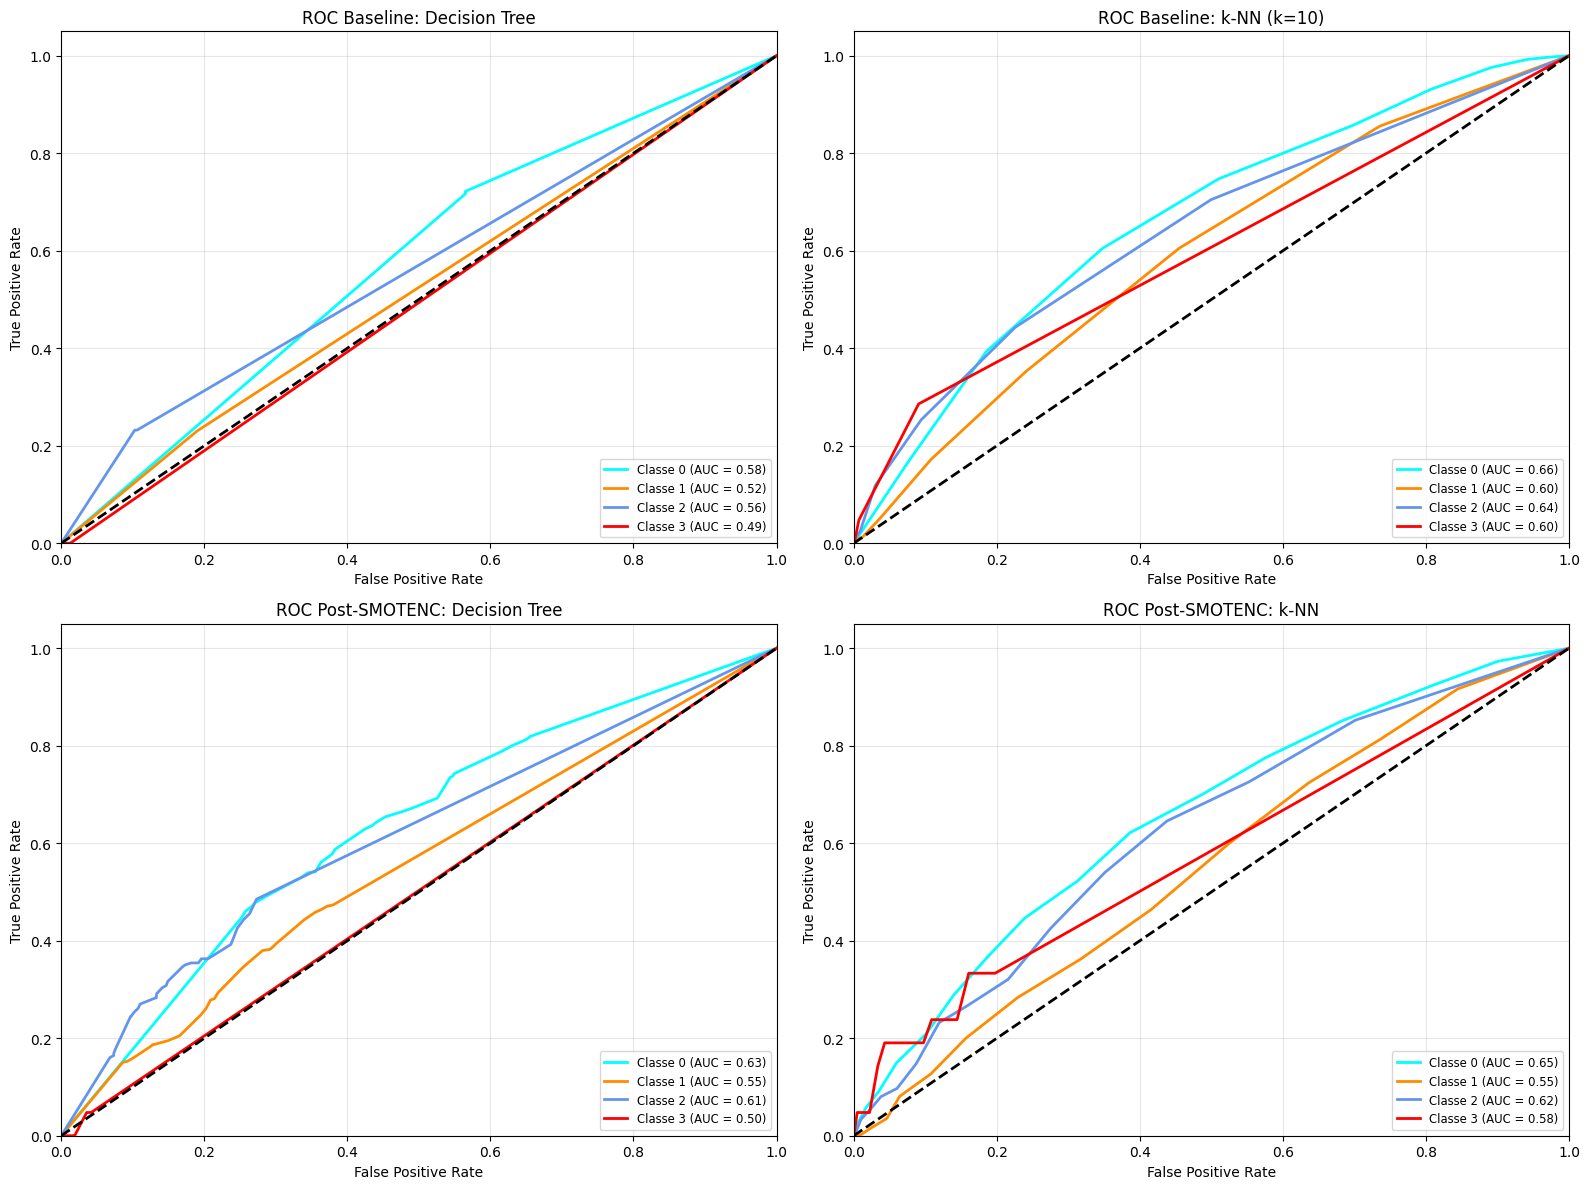

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

def plot_all_roc_curves(dt_base, knn_base, grid_dt, grid_knn, X_test, X_test_scaled, y_test):
    classes = [0, 1, 2, 3]
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = len(classes)
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'red']

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Lista dei modelli e dei dati corrispondenti per il loop
    # Formato: (modello, dati_x, titolo, asse)
    models_info = [
        (dt_base, X_test, "ROC Baseline: Decision Tree", axes[0, 0]),
        (knn_base, X_test_scaled, "ROC Baseline: k-NN (k=10)", axes[0, 1]),
        (grid_dt, X_test, "ROC Post-SMOTENC: Decision Tree", axes[1, 0]),
        (grid_knn, X_test, "ROC Post-SMOTENC: k-NN", axes[1, 1])
    ]

    for model, x_data, title, ax in models_info:
        # Otteniamo le probabilità
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(x_data)
        else:
            # Per GridSearchCV usiamo il best_estimator_
            y_score = model.best_estimator_.predict_proba(x_data)

        for i, color in zip(range(n_classes), colors):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'Classe {i} (AUC = {roc_auc:.2f})')

        ax.plot([0, 1], [0, 1], 'k--', lw=2)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(title)
        ax.legend(loc="lower right", fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Esecuzione del confronto finale
plot_all_roc_curves(dt_base, knn_base, grid_dt, grid_knn, X_test, X_test_scaled, y_test)

In [5]:
X_train_resampled, y_train_resampled = smote_fast.fit_resample(X_train, y_train)

print("Distribuzione Target 'sii' (Training Set Post-SMOTENC):")
print(y_train_resampled.value_counts().sort_index())

Distribuzione Target 'sii' (Training Set Post-SMOTENC):
sii
0.0    4354
1.0    4354
2.0    4354
3.0    4354
Name: count, dtype: int64
